In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from PIL import Image
import glob
import pandas as pd

In [1]:
ref = plt.imread('/home/ferbue/BKSVD-Python/data/Reference.jpg')
plt.imshow(ref)

NameError: name 'plt' is not defined

(256, 256, 3)


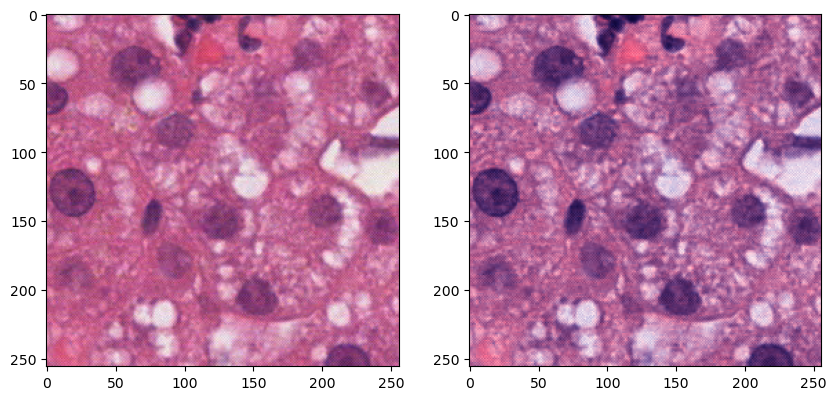

In [3]:
plt.figure(figsize=(10,5))
img_0 = (plt.imread('/home/ferbue/BKSVD-Python/data/hist0.png')*255).astype(np.uint8)[:,:,:3]
plt.subplot(121),plt.imshow(img_0)
norm_0 = (plt.imread('/home/ferbue/BKSVD-Python/data/norm_0.png')*255).astype(np.uint8)[:,:,:3]
plt.subplot(122),plt.imshow(norm_0)

print(img_0.shape)


(<Axes: >,
 (array([  778.,  5140., 12529., 26254., 26906., 42180., 37901., 24912.,
         14942.,  5066.]),
  array([  5.,  30.,  55.,  80., 105., 130., 155., 180., 205., 230., 255.]),
  <BarContainer object of 10 artists>))

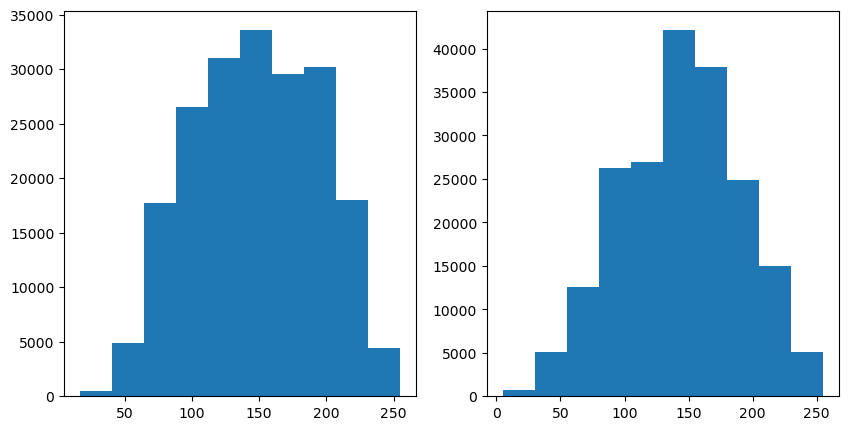

In [4]:
plt.figure(figsize=(10,5))
plt.subplot(121),plt.hist(img_0.flatten())
plt.subplot(122),plt.hist(norm_0.flatten())

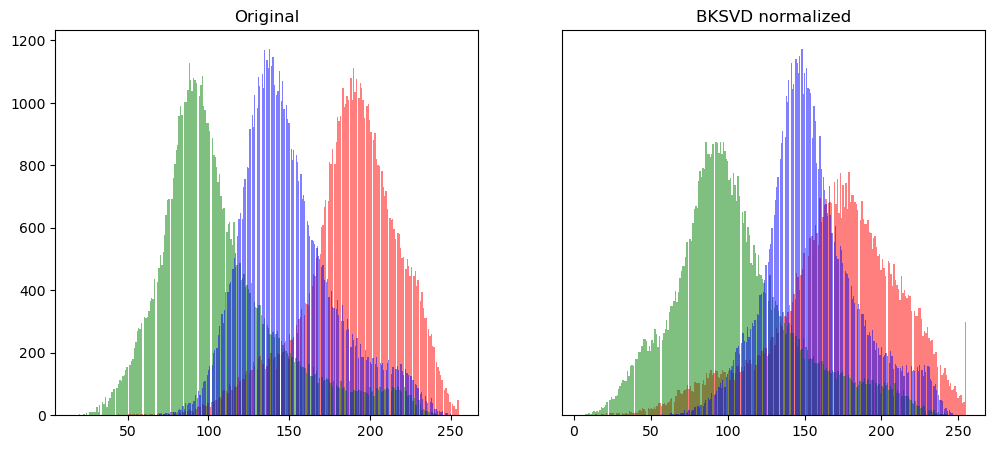

In [5]:
plt.figure(figsize=(12,5))
colors = ['red','green','blue']
plt.subplot(121)
for i in range(3):
    channel= img_0[:,:,i]
    plt.hist(channel.ravel(), bins=256, color=colors[i], alpha=0.5)
    plt.title('Original')
plt.subplot(122)
plt.yticks([])
for i in range(3):
    channel= norm_0[:,:,i]
    plt.hist(channel.ravel(), bins=256, color=colors[i], alpha=0.5)
    plt.title('BKSVD normalized')

46 233


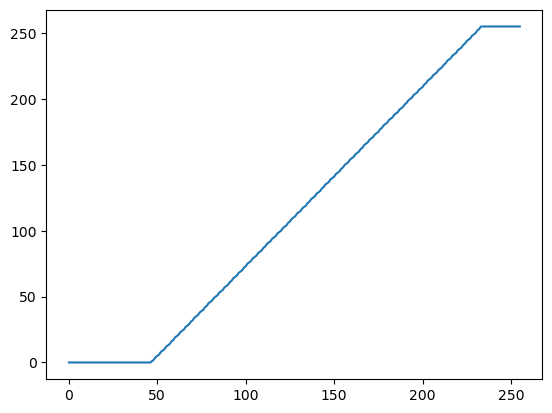

In [6]:
vmin = np.percentile(img_0,0.5).astype(np.uint8)
vmax = np.percentile(img_0,98).astype(np.uint8)
print(vmin,vmax)

LUT = np.arange(256)
LUT[:vmin]=0
LUT[vmax:]=255
LUT[vmin:vmax]=(255/(vmax-vmin))*(LUT[vmin:vmax]-vmin)

plt.plot(LUT)


(<Axes: title={'center': 'New'}>,
 Text(0.5, 1.0, 'New'))

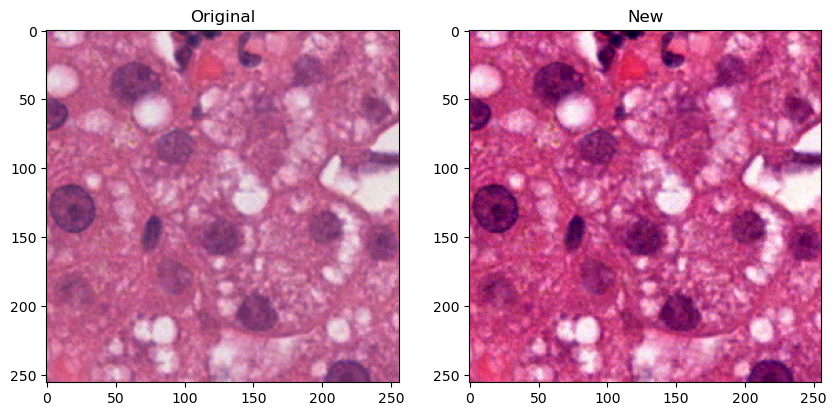

In [7]:
new_img = np.zeros(img_0.shape).astype(np.uint8)
for i in range(3):
    channel= img_0[:,:,i]
    new_img[:,:,i]= LUT[channel]

plt.figure(figsize=(10,5))
plt.subplot(121),plt.imshow(img_0), plt.title('Original')
plt.subplot(122),plt.imshow(new_img), plt.title('New')


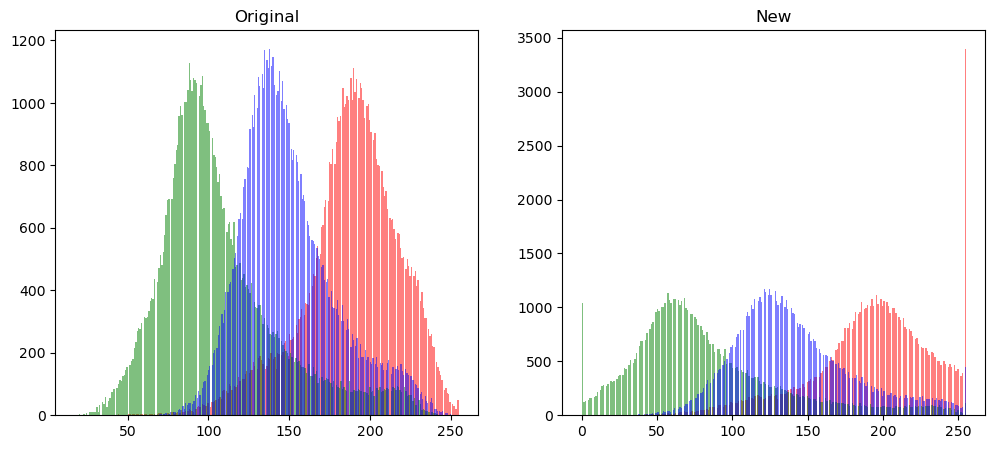

In [8]:
plt.figure(figsize=(12,5))
colors = ['red','green','blue']
plt.subplot(121)
for i in range(3):
    channel= img_0[:,:,i]
    plt.hist(channel.ravel(), bins=256, color=colors[i], alpha=0.5)
    plt.title('Original')
plt.subplot(122)
# plt.yticks([])
for i in range(3):
    channel= new_img[:,:,i]
    plt.hist(channel.ravel(), bins=256, color=colors[i], alpha=0.5)
    plt.title('New')

In [9]:
Rein_img = np.zeros(img_0.shape).astype('uint8')
for i in range(3):
    channel= img_0[:,:,i]
    target_ch = ref[:,:,i]
    t_std = np.std(target_ch)
    t_mean = np.mean(target_ch)
    Rein_img[:,:,i]= (((channel-np.mean(channel))/np.std(channel))*t_std + t_mean).clip(0,255).astype('uint8')

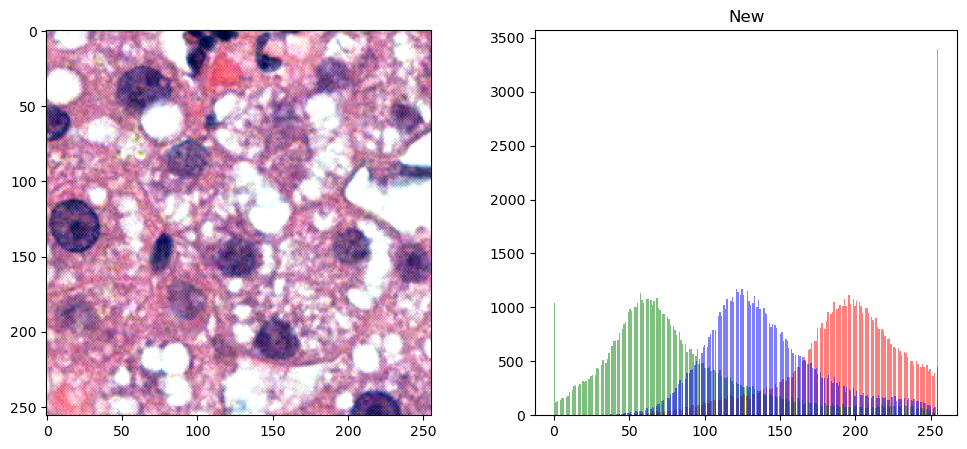

In [10]:
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.imshow(Rein_img)
plt.subplot(122)
# plt.yticks([])
for i in range(3):
    channel= new_img[:,:,i]
    plt.hist(channel.ravel(), bins=256, color=colors[i], alpha=0.5)
    plt.title('New')


# Basic LUT combination

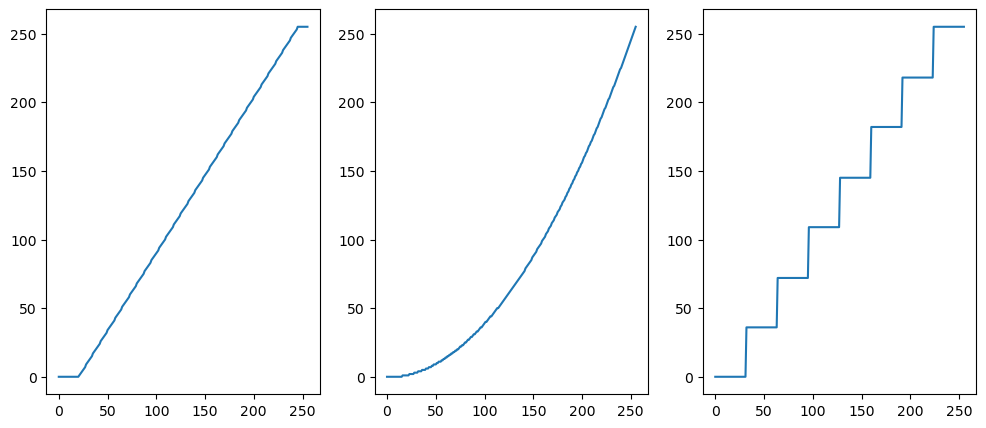

In [11]:
plt.figure(figsize=(12,5))
plt.subplot(131)
vmin=20
vmax=245
LUT1 = np.arange(256)
LUT1[:vmin]=0
LUT1[vmax:]=255
LUT1[vmin:vmax]=(255/(vmax-vmin))*(LUT1[vmin:vmax]-vmin)
plt.plot(LUT1)

plt.subplot(132)
LUT2 = np.arange(256)
LUT2 = ((LUT2**2/255**2)*255).astype('uint8')
plt.subplot(132)
LUT2 = np.arange(256)
LUT2 = ((LUT2**2/255**2)*255).astype('uint8')
plt.plot(LUT2)

plt.subplot(133)
LUT3 = ((np.arange(256)//32)/(255//32)*255).astype('uint8')
plt.plot(LUT3)

In [12]:
255/7

36.42857142857143

/home/ferbue/anaconda3/envs/chime_env_v2_1/lib/python3.8/site-packages/matplotlib/text.py:1279: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if s != self._text:


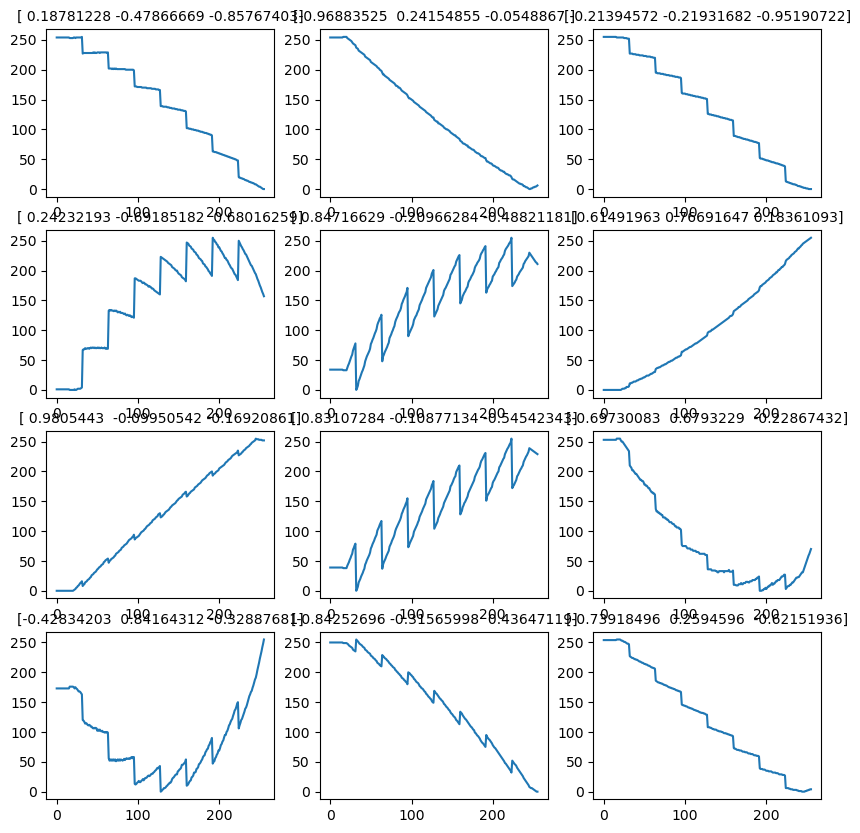

In [13]:
plt.figure(figsize=(10,10))

for i in range(12):
    plt.subplot(4,3,i+1)

    weights = np.random.randn(3)
    weights = weights/np.linalg.norm(weights)
    LUTmix = weights[0]*LUT1+weights[1]*LUT2+weights[2]*LUT3

    LUTmix-=LUTmix.min()
    LUTmix = LUTmix/LUTmix.max()
    LUTmix = (255*LUTmix).astype('uint8')
    
    plt.plot(LUTmix)
    # plt.axis('off')
    plt.title(weights, fontsize=10)

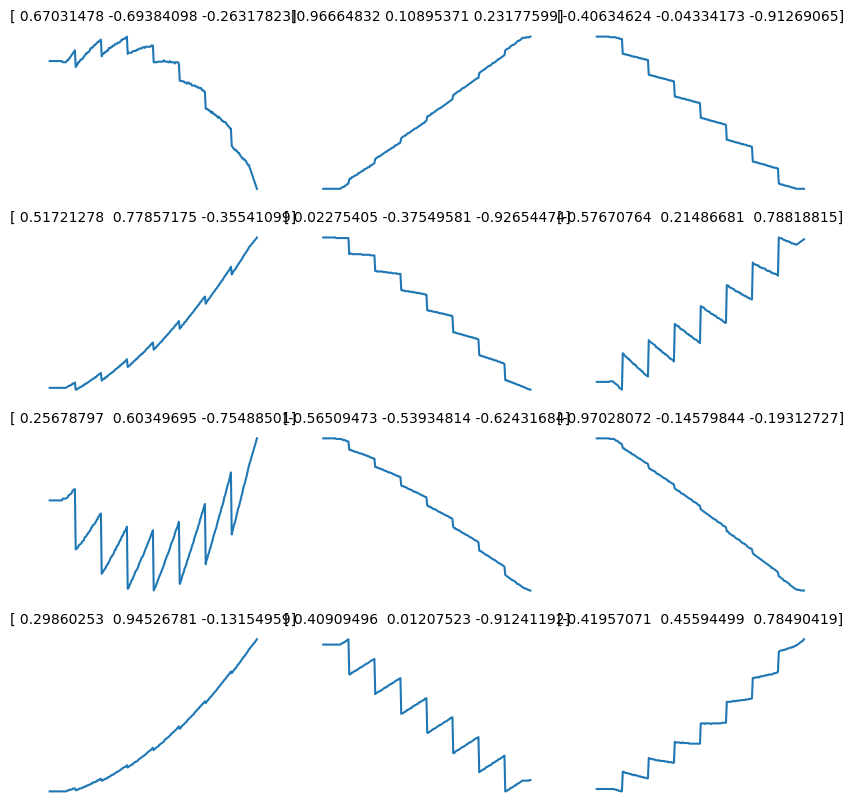

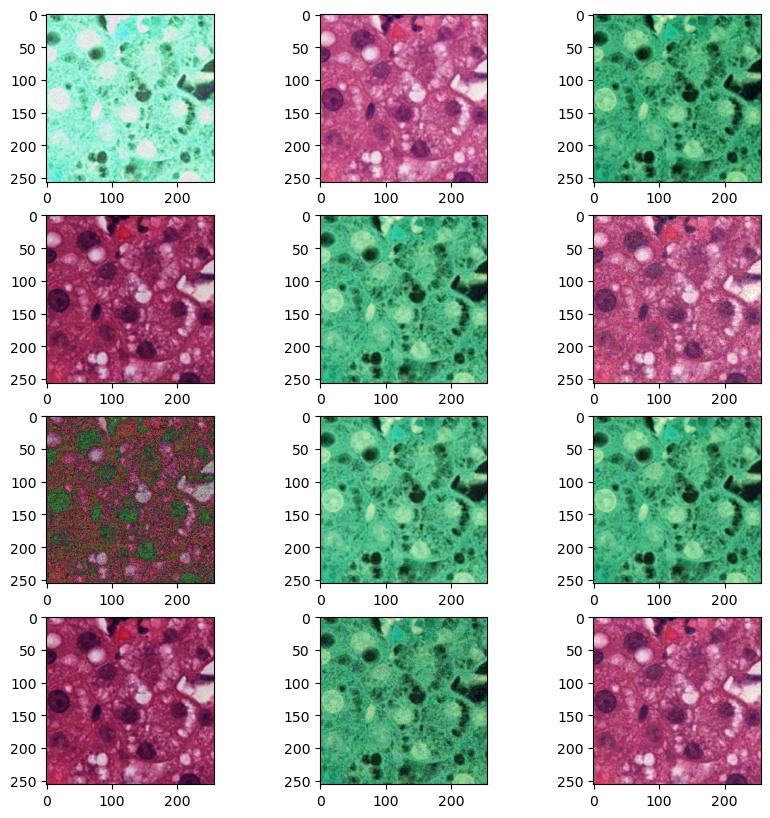

In [14]:
plt.figure(1, figsize=(10,10))
plt.figure(2, figsize=(10,10))
for i in range(12):
    plt.figure(1)
    plt.subplot(4,3,i+1)

    weights = np.random.randn(3)
    weights = weights/np.linalg.norm(weights)
    LUTmix = weights[0]*LUT1+weights[1]*LUT2+weights[2]*LUT3

    LUTmix-=LUTmix.min()
    LUTmix = LUTmix/LUTmix.max()
    LUTmix = (255*LUTmix).astype('uint8')
    
    plt.plot(LUTmix)
    plt.axis('off')
    plt.title(weights, fontsize=10)

    plt.figure(2)
    plt.subplot(4,3,i+1)

    crazy_img = np.zeros(img_0.shape).astype(np.uint8)
    for i in range(3):
        channel= img_0[:,:,i]
        crazy_img[:,:,i]= LUTmix[channel]
    plt.imshow(crazy_img)


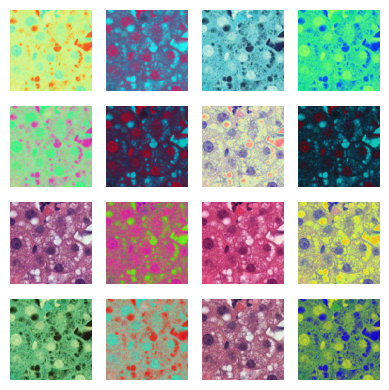

In [29]:
plt.figure(1, figsize=(4,4))

for i in range(4*4):

    
    plt.subplot(4,4,i+1)
    crazy_img = np.zeros(img_0.shape).astype(np.uint8)
    for i in range(3):
        weights = np.random.randn(3)
        weights = weights/np.linalg.norm(weights)
        LUTmix = weights[0]*LUT1+weights[1]*LUT2+weights[2]*LUT3
    
        LUTmix-=LUTmix.min()
        LUTmix = LUTmix/LUTmix.max()
        LUTmix = (255*LUTmix).astype('uint8')
        
       
        # plt.subplot(4,3,i+1)


    
        channel= img_0[:,:,i]
        crazy_img[:,:,i]= LUTmix[channel]
    plt.imshow(crazy_img),plt.axis('off')
plt.tight_layout()
# plt.savefig('stainwall.png')

In [2]:
import pickle

def od2rgb(od):
    """Converts optical density to RGB."""
    return np.clip(256 * np.exp(-od) - 1,0,255).astype('uint8')

def rgb2od(rgb):
    """Converts RGB to optical density."""
    # Add a small epsilon to avoid taking the log of zero
    eps = 1e-6
    return -np.log((rgb.astype(float) + 1) / 256 + eps)

Landini_pair = np.array([[0.6443,0.7167,0.2669],[0.0900,0.9545,0.2832]])
Landini_pair = Landini_pair/np.linalg.norm(Landini_pair,axis=1)[:,None]
Landini_rgb = od2rgb(Landini_pair)

In [3]:
Landini_pair

array([[0.64429453, 0.71669391, 0.26689773],
       [0.09002825, 0.95479962, 0.2832889 ]])

In [ ]:
np.maximum(-1*np.log(1/255),1e-6) #[1e-6] --> inf (log(1/255) = 5.54)

5.541263545158426

In [3]:
with open('/mnt/chimeracknas5data2/preproc-slides/SCANB_MALMO/SCANB_Malmo_224x224/processed-data/SCANB_Malmo_pil_10.4_224px/batches/Batch_1/macenko_normalisation/dataframes_macenko/df_stain_wsis.pkl','rb') as f:
    macenko_stains = pickle.load(f)

In [6]:
macenko_stains

,slide,stain,concentration,p,error
0,SCANB_MALMO_RiDn0038_slide_161731_WSI_clean,"[[0.5326743408777561, 0.7365819836523144, 0.41...","[0.8113886880832621, 0.23776326658617153]",237.0,None
1,SCANB_MALMO_RiDn0040_slide_429123_WSI_clean,"[[0.5096161135588235, 0.721590267726931, 0.468...","[0.5496931532859043, 0.23260226343166157]",239.0,None
2,SCANB_MALMO_RiDn0070_slide_528612_WSI_clean,"[[0.5533042514616126, 0.7185127265943041, 0.42...","[0.7373548059305232, 0.21076615407341007]",239.0,None
3,SCANB_MALMO_RiDn0073_slide_555069_WSI_clean,"[[0.599921695169933, 0.6623977540598309, 0.448...","[0.4804309734488931, 0.29887906287007593]",237.0,None
4,SCANB_MALMO_RiDn0075_slide_264585_WSI_clean,"[[0.4943378711204829, 0.7088617639395058, 0.50...","[0.5320995772550721, 0.3754035017668801]",237.0,None
...,...,...,...,...,...
606,SCANB_MALMO_RiDn8185_slide_425100_WSI_clean,"[[0.5917619418141677, 0.6636192274649537, 0.45...","[0.9025072160861064, 0.259513341561524]",240.0,None
607,SCANB_MALMO_RiDn8195_slide_456215_WSI_clean,"[[0.5566676840310907, 0.7319532219366902, 0.39...","[1.3582908250311614, 0.5304921541961707]",236.0,None
608,SCANB_MALMO_RiDn8205_slide_713863_WSI_clean,"[[0.587739401751213, 0.6832076772351594, 0.433...","[1.1834896734478795, 0.35543683855284636]",236.0,None
609,SCANB_MALMO_RiDn8260_slide_763292_WSI_clean,"[[0.5116836126777466, 0.7447787053485407, 0.42...","[0.6593702715296799, 0.2209875237516846]",237.0,None


In [ ]:
macenko_stains['stain'][0]


array([[ 0.53267434,  0.73658198,  0.41677935],
       [-0.08851263,  0.94287209,  0.32118177]])

In [5]:
stain_pair = macenko_stains['stain'][0]
distance = np.linalg.norm(stain_pair[0,:]-stain_pair[1,:])
distance

0.6614890449684991

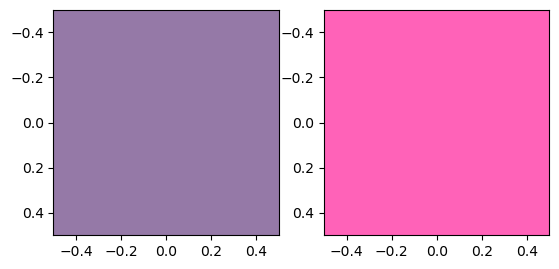

In [13]:
rgb_stain = od2rgb(macenko_stains['stain'][0])
rgb_stain[0,:].reshape(1,1,3)
plt.subplot(121)
plt.imshow(rgb_stain[0,:].reshape(1,1,3))
plt.subplot(122)
plt.imshow(rgb_stain[1,:].reshape(1,1,3))

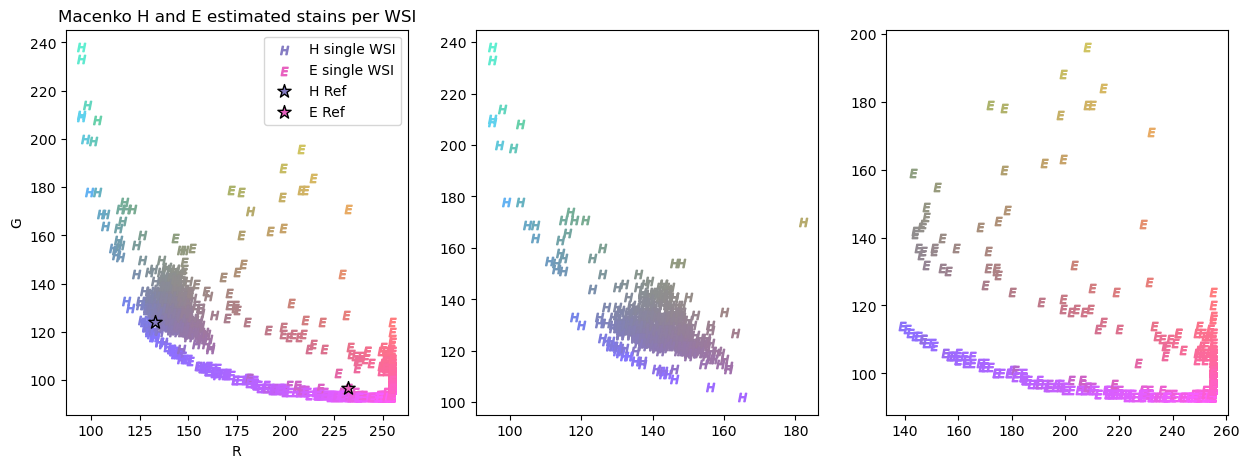

In [15]:
plt.figure(figsize=(15,5))
for stain_pair in macenko_stains['stain']:
    rgb_pair = od2rgb(stain_pair)
    plt.subplot(132)
    plt.scatter(rgb_pair[0,0], rgb_pair[0,1], marker='$H$', color=rgb_pair[0,:]/255)
    plt.subplot(133)
    plt.scatter(rgb_pair[1,0], rgb_pair[1,1], marker='$E$', color=rgb_pair[1,:]/255)
    plt.subplot(131)
    plt.scatter(rgb_pair[0,0], rgb_pair[0,1], marker='$H$', color=rgb_pair[0,:]/255)
    plt.scatter(rgb_pair[1,0], rgb_pair[1,1], marker='$E$', color=rgb_pair[1,:]/255)
    plt.xlabel('R')
    plt.ylabel('G')
    plt.title('Macenko H and E estimated stains per WSI')

plt.scatter(Landini_rgb[0,0], Landini_rgb[0,1], marker='$H$', color=Landini_rgb[0,:]/255,  label='H single WSI')
plt.scatter(Landini_rgb[1,0], Landini_rgb[1,1], marker='$E$', color=Landini_rgb[1,:]/255,  label='E single WSI')
plt.scatter(Landini_rgb[0,0], Landini_rgb[0,1], marker='*', color=Landini_rgb[0,:]/255, edgecolors='k', s=100, label='H Ref')
plt.scatter(Landini_rgb[1,0], Landini_rgb[1,1], marker='*', color=Landini_rgb[1,:]/255, edgecolors='k', s=100, label='E Ref')

plt.legend()

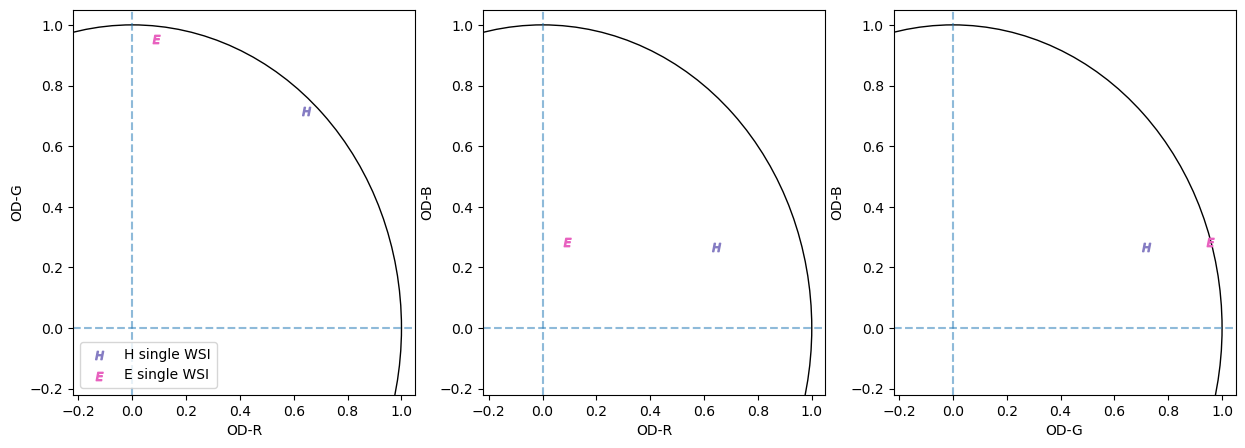

In [5]:
labels = ['OD-R','OD-G','OD-B']
fig = plt.figure(figsize=(15,5))

for i in range(3):   
    for j in range(i+1,3):
        index = i+j
        ax = fig.add_subplot(1,3,index)
        circle = plt.Circle((0, 0), 1, fill=False)
        # Add circle to plot
        ax.add_patch(circle)
        plt.axhline(0, linestyle='--', alpha=0.5 )  # dashed line at y=0
        plt.axvline(0, linestyle='--', alpha=0.5 )  # dashed line at x=0

        plt.scatter(Landini_pair[0,i], Landini_pair[0,j], marker='$H$', color=Landini_rgb[0,:]/255,  label='H single WSI')
        plt.scatter(Landini_pair[1,i], Landini_pair[1,j], marker='$E$', color=Landini_rgb[1,:]/255,  label='E single WSI')
        # plt.scatter(Landini_pair[0,i], Landini_pair[0,j], marker='*', color=Landini_rgb[0,:]/255, edgecolors='k', s=100, label='H Ref')
        # plt.scatter(Landini_pair[1,i], Landini_pair[1,j], marker='*', color=Landini_rgb[1,:]/255, edgecolors='k', s=100, label='E Ref')
        # Create circle
        ax.set_xlim(-0.22, 1.05)
        ax.set_ylim(-0.22, 1.05)
        plt.xlabel(labels[i])
        plt.ylabel(labels[j])   
        if(index==1):
            plt.legend(loc=3)

        


0 1
0 2
1 2


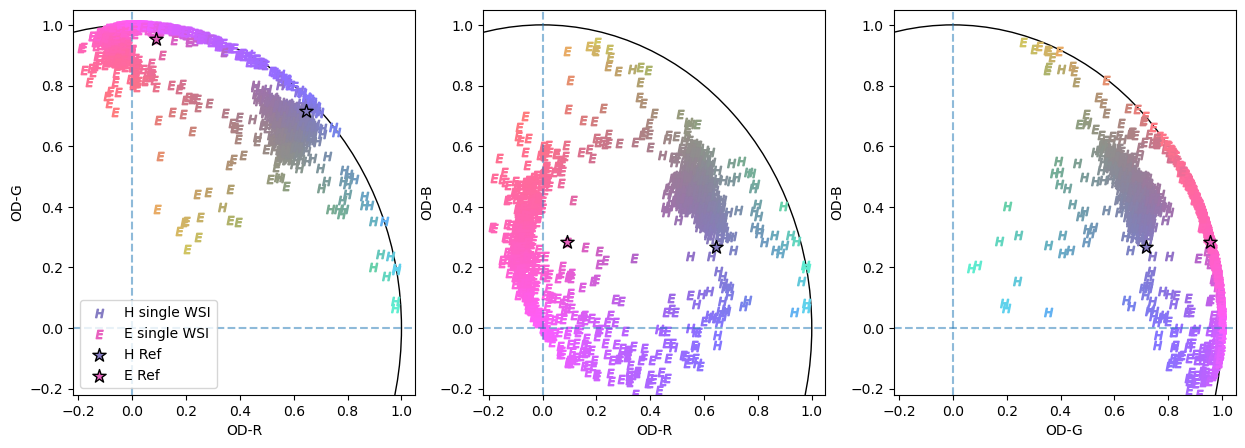

In [16]:
labels = ['OD-R','OD-G','OD-B']
fig = plt.figure(figsize=(15,5))

for i in range(3):   
    for j in range(i+1,3):
        index = i+j
        ax = fig.add_subplot(1,3,index)
        circle = plt.Circle((0, 0), 1, fill=False)
        # Add circle to plot
        ax.add_patch(circle)
        plt.axhline(0, linestyle='--', alpha=0.5 )  # dashed line at y=0
        plt.axvline(0, linestyle='--', alpha=0.5 )  # dashed line at x=0
        print(i,j)
        for stain_pair in macenko_stains['stain'][:]:
            rgb_pair = od2rgb(stain_pair)
            plt.scatter(stain_pair[0,i], stain_pair[0,j], marker='$H$', color=rgb_pair[0,:]/255)
            plt.scatter(stain_pair[1,i], stain_pair[1,j], marker='$E$', color=rgb_pair[1,:]/255)
            plt.xlabel(labels[i])
            plt.ylabel(labels[j])
        plt.scatter(Landini_pair[0,i], Landini_pair[0,j], marker='$H$', color=Landini_rgb[0,:]/255,  label='H single WSI')
        plt.scatter(Landini_pair[1,i], Landini_pair[1,j], marker='$E$', color=Landini_rgb[1,:]/255,  label='E single WSI')
        plt.scatter(Landini_pair[0,i], Landini_pair[0,j], marker='*', color=Landini_rgb[0,:]/255, edgecolors='k', s=100, label='H Ref')
        plt.scatter(Landini_pair[1,i], Landini_pair[1,j], marker='*', color=Landini_rgb[1,:]/255, edgecolors='k', s=100, label='E Ref')
        # Create circle
        ax.set_xlim(-0.22, 1.05)
        ax.set_ylim(-0.22, 1.05)
        if(index==1):
            plt.legend(loc=3)

        


In [17]:
invalid = 0
eps = 0
for stain_pair in macenko_stains['stain'][:]:
    if np.any(stain_pair<0):
        invalid+=1

invalid_pct = invalid/len(macenko_stains)
print(invalid)
print("{:.2f}".format(invalid_pct))

471
0.77


In [1]:
471/611

0.7708674304418985

0 1
0 2
1 2


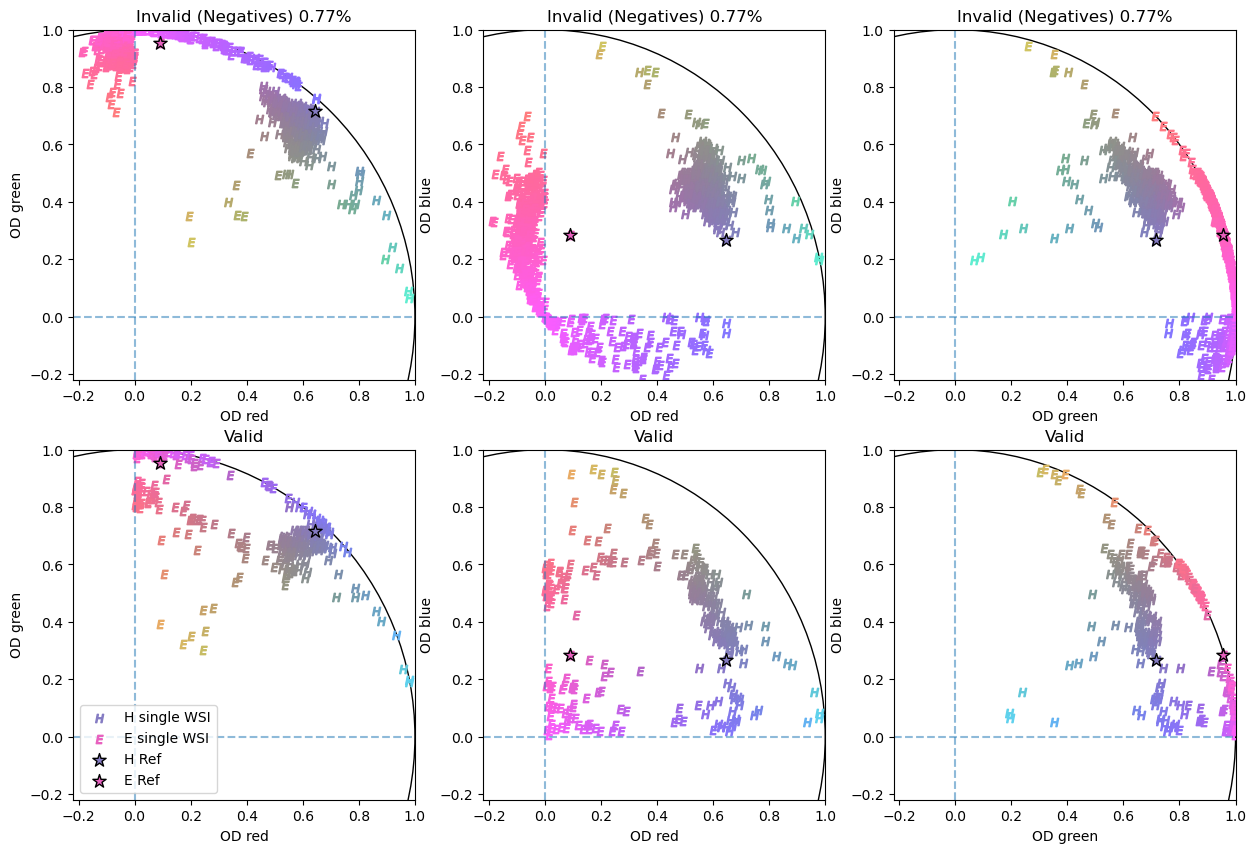

In [18]:
labels = ['OD-R','OD-G','OD-B']
labels = ['red', 'green', 'blue']
fig = plt.figure(figsize=(15,10))

for i in range(3):   
    for j in range(i+1,3):
        index = i+j
        ax = fig.add_subplot(2,3,index)
        ax2 = fig.add_subplot(2,3,index+3)
        circle = plt.Circle((0, 0), 1, fill=False)
        circle2 = plt.Circle((0, 0), 1, fill=False)
        # Add circle to plot
        ax.add_patch(circle)
        ax.axhline(0, linestyle='--', alpha=0.5 )  # dashed line at y=0
        ax.axvline(0, linestyle='--', alpha=0.5 )  # dashed line at x=0
        ax.set_title('Invalid (Negatives)'+" {:.2f}%".format(invalid_pct))

        ax2.add_patch(circle2)
        ax2.axhline(0, linestyle='--', alpha=0.5 )  # dashed line at y=0
        ax2.axvline(0, linestyle='--', alpha=0.5 )  # dashed line at x=0
        ax2.set_title('Valid')
        print(i,j)
        for stain_pair in macenko_stains['stain'][:]:
            rgb_pair = od2rgb(stain_pair)
            if np.any(stain_pair<-1e-3):
                ax.scatter(stain_pair[0,i], stain_pair[0,j], marker='$H$', color=rgb_pair[0,:]/255)
                ax.scatter(stain_pair[1,i], stain_pair[1,j], marker='$E$', color=rgb_pair[1,:]/255)
                
            else:
                ax2.scatter(stain_pair[0,i], stain_pair[0,j], marker='$H$', color=rgb_pair[0,:]/255)
                ax2.scatter(stain_pair[1,i], stain_pair[1,j], marker='$E$', color=rgb_pair[1,:]/255)
                

        for plot in [ax, ax2]:
            plot.set_xlabel('OD '+labels[i])
            plot.set_ylabel('OD '+labels[j])
            plot.scatter(Landini_pair[0,i], Landini_pair[0,j], marker='$H$', color=Landini_rgb[0,:]/255,  label='H single WSI')
            plot.scatter(Landini_pair[1,i], Landini_pair[1,j], marker='$E$', color=Landini_rgb[1,:]/255,  label='E single WSI')
            plot.scatter(Landini_pair[0,i], Landini_pair[0,j], marker='*', color=Landini_rgb[0,:]/255, edgecolors='k', s=100, label='H Ref')
            plot.scatter(Landini_pair[1,i], Landini_pair[1,j], marker='*', color=Landini_rgb[1,:]/255, edgecolors='k', s=100, label='E Ref')
        # Create circle
        ax.set_xlim(-0.22, 1)
        ax.set_ylim(-0.22, 1)
        ax2.set_xlim(-0.22, 1)
        ax2.set_ylim(-0.22, 1)
        if(index==1):
            plt.legend(loc=3)

        


0 1


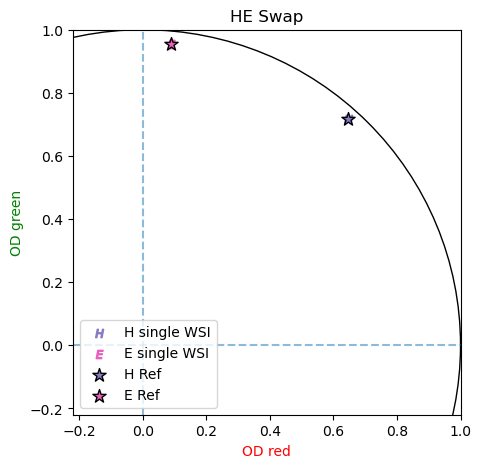

In [19]:
labels = ['OD-R','OD-G','OD-B']
labels = ['red', 'green', 'blue']
fig = plt.figure(figsize=(5,5))

for i in range(1):   
    for j in range(i+1,2):
        index = i+j
        ax = fig.add_subplot()

        circle = plt.Circle((0, 0), 1, fill=False)
        # Add circle to plot
        ax.add_patch(circle)
        ax.axhline(0, linestyle='--', alpha=0.5 )  # dashed line at y=0
        ax.axvline(0, linestyle='--', alpha=0.5 )  # dashed line at x=0
        ax.set_title('HE Swap')

        print(i,j)
        for stain_pair in macenko_stains['stain'][:]:
            rgb_pair = od2rgb(stain_pair)
            if stain_pair[1,0]>stain_pair[0,0]:
                ax.scatter(stain_pair[0,i], stain_pair[0,j], marker='$H$', color=rgb_pair[0,:]/255)
                ax.scatter(stain_pair[1,i], stain_pair[1,j], marker='$E$', color=rgb_pair[1,:]/255)
                
                

        for plot in [ax]:
            plot.set_xlabel('OD '+labels[i])
            plot.set_ylabel('OD '+labels[j])
            plot.scatter(Landini_pair[0,i], Landini_pair[0,j], marker='$H$', color=Landini_rgb[0,:]/255,  label='H single WSI')
            plot.scatter(Landini_pair[1,i], Landini_pair[1,j], marker='$E$', color=Landini_rgb[1,:]/255,  label='E single WSI')
            plot.scatter(Landini_pair[0,i], Landini_pair[0,j], marker='*', color=Landini_rgb[0,:]/255, edgecolors='k', s=100, label='H Ref')
            plot.scatter(Landini_pair[1,i], Landini_pair[1,j], marker='*', color=Landini_rgb[1,:]/255, edgecolors='k', s=100, label='E Ref')
        # Create circle
        ax.set_xlim(-0.22, 1)
        ax.set_ylim(-0.22, 1)
        ax.xaxis.label.set_color(labels[i])
        ax.yaxis.label.set_color(labels[j])

        if(index==1):
            plt.legend(loc=3)

        


In [20]:
all_distances = np.zeros(len(macenko_stains['stain']))
for i,stain_pair in enumerate(macenko_stains['stain']):
    distance = np.linalg.norm(stain_pair[0,:]-stain_pair[1,:])
    all_distances[i]=distance

(-0.22, 1.0)

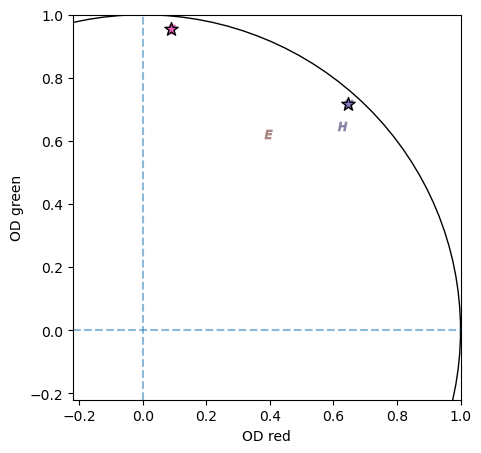

In [85]:
index = np.argmin(all_distances)
stain_pair = macenko_stains['stain'][index]
rgb_pair = od2rgb(stain_pair)
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot()
circle = plt.Circle((0, 0), 1, fill=False)
# Add circle to plot
ax.add_patch(circle)
ax.axhline(0, linestyle='--', alpha=0.5 )  # dashed line at y=0
ax.axvline(0, linestyle='--', alpha=0.5 )  # dashed line at x=0
i=0
j=1

ax.scatter(stain_pair[0,i], stain_pair[0,j], marker='$H$', color=rgb_pair[0,:]/255)
ax.scatter(stain_pair[1,i], stain_pair[1,j], marker='$E$', color=rgb_pair[1,:]/255)
ax.set_xlabel('OD '+labels[i])
ax.set_ylabel('OD '+labels[j])
ax.scatter(Landini_pair[0,i], Landini_pair[0,j], marker='$H$', color=Landini_rgb[0,:]/255,  label='H single WSI')
ax.scatter(Landini_pair[1,i], Landini_pair[1,j], marker='$E$', color=Landini_rgb[1,:]/255,  label='E single WSI')
ax.scatter(Landini_pair[0,i], Landini_pair[0,j], marker='*', color=Landini_rgb[0,:]/255, edgecolors='k', s=100, label='H Ref')
ax.scatter(Landini_pair[1,i], Landini_pair[1,j], marker='*', color=Landini_rgb[1,:]/255, edgecolors='k', s=100, label='E Ref')

# Focus
ax.set_xlim(-0.22, 1)
ax.set_ylim(-0.22, 1)


In [21]:
original_path = '/mnt/ssd/bojing/Image-Adaptive-3DLUT/data/Batch_1/tiles/'
macenko_path = '/mnt/ssd/bojing/Image-Adaptive-3DLUT/data/Batch_1/macenko_normalisation/tiles_macenko/'
index = np.argmax(all_distances) # SCANB_MALMO_RiDn0435_slide_657348_WSI_clean
slide = macenko_stains['slide'][index]
print(slide)

tiles = glob.glob(original_path+slide+'/'+slide+'/*.jpg')
# tiles = glob.glob(macenko_path+slide+'/'+slide+'/*.jpg')
# tiles[0]



NameError: name 'all_distances' is not defined

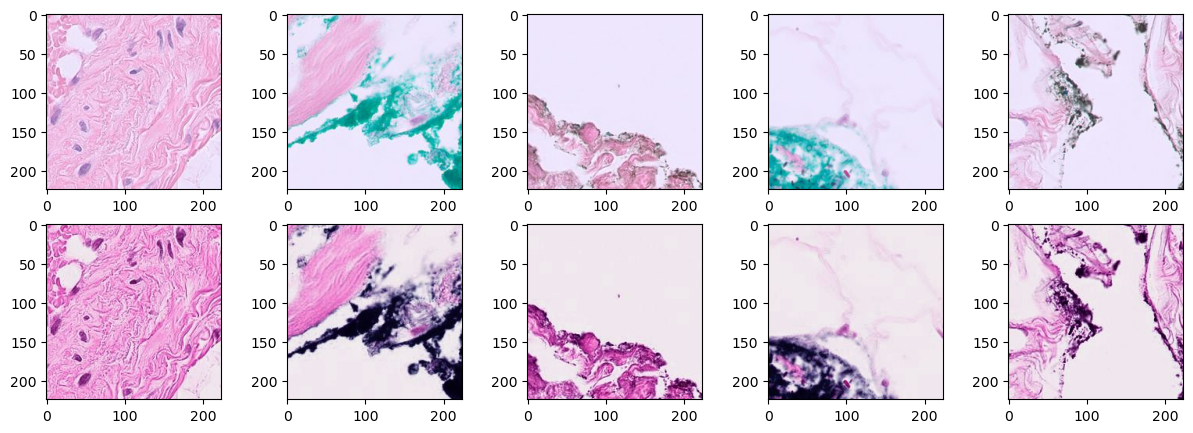

In [84]:
# Looking for interesting patches
#  init = 200
# end = init+25
# samples = [6, 18, 4, 31, 25, 61, 75, 80, 76, 137, 125, 159, 170, 186, 195, 203, 220, 224, 210]
# samples = np.arange(init,end)
# plt.figure(figsize=(15,5))
# for i, sample in enumerate(samples[]):
#     img_0_path = tiles[sample]
#     img_0 = plt.imread(tiles[sample])
#     plt.subplot(5,5,i+1)
#     plt.imshow(img_0)
#     plt.title(sample)


np.random.seed(3) 
# 3 cauterized turned H
# 8 nice patch
samples = [6, 18, 4, 31, 25, 61, 75, 80, 76, 137, 125, 159, 170, 186, 195, 203, 220, 224, 210]
plt.figure(figsize=(15,5))
for i, sample in enumerate(samples[:5]):
    img_0_path = tiles[sample]
    img_0 = plt.imread(tiles[sample])
    plt.subplot(2,5,i+1)
    plt.imshow(img_0)

    img_macenko_path = img_0_path.replace(original_path,macenko_path).replace('.jpg','_macenko.jpg')
    img_mac = plt.imread(img_macenko_path)
    plt.subplot(2,5,i+1+5)
    plt.imshow(img_mac)






In [20]:
original_path = '/mnt/ssd/bojing/Image-Adaptive-3DLUT/data/Batch_1/tiles/'
macenko_path = '/mnt/ssd/bojing/Image-Adaptive-3DLUT/data/Batch_1/macenko_normalisation/tiles_macenko/'
index = np.argmin(all_distances) # SCANB_MALMO_RiDn6783_slide_242848_WSI_clean
slide = macenko_stains['slide'][index]
print(slide)

tiles = glob.glob(original_path+slide+'/'+slide+'/*.jpg')
# tiles = glob.glob(macenko_path+slide+'/'+slide+'/*.jpg')
# tiles[0]



NameError: name 'all_distances' is not defined

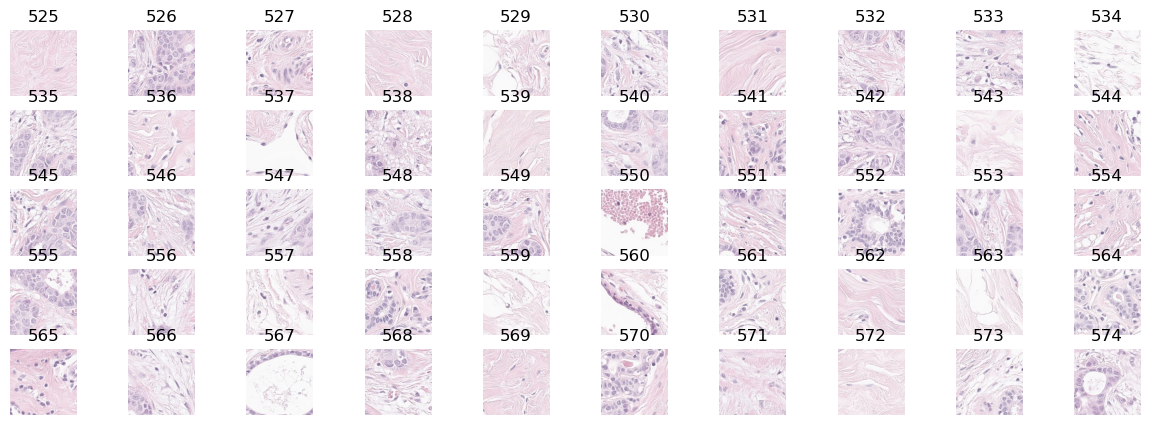

In [105]:
# Looking for interesting patches
init = 525
end = init+50
samples = [0, 11, 30, 102, 118, 417, 560, 559, 570 ]
samples = np.arange(init,end)
plt.figure(figsize=(15,5))
for i, sample in enumerate(samples[:]):
    img_0_path = tiles[sample]
    img_0 = plt.imread(tiles[sample])
    plt.subplot(5,10,i+1)
    plt.imshow(img_0), plt.axis('off')
    plt.title(sample)


# np.random.seed(3) 
# # 3 cauterized turned H
# # 8 nice patch
# samples = [6, 18, 4, 31, 25, 61, 75, 80, 76, 137, 125, 159, 170, 186, 195, 203, 220, 224, 210]
# plt.figure(figsize=(15,5))
# for i, sample in enumerate(samples[:5]):
#     img_0_path = tiles[sample]
#     img_0 = plt.imread(tiles[sample])
#     plt.subplot(2,5,i+1)
#     plt.imshow(img_0)

#     img_macenko_path = img_0_path.replace(original_path,macenko_path).replace('.jpg','_macenko.jpg')
#     img_mac = plt.imread(img_macenko_path)
#     plt.subplot(2,5,i+1+5)
#     plt.imshow(img_mac)






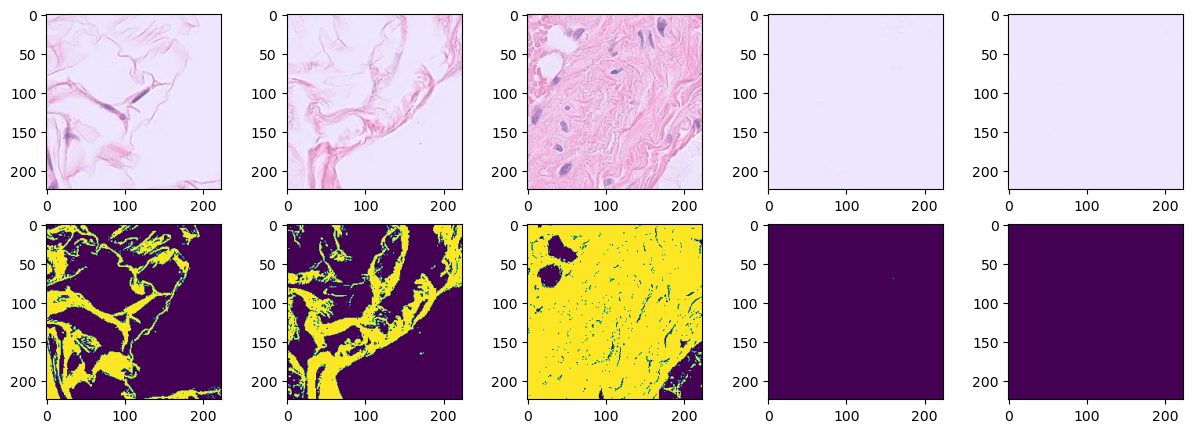

In [63]:
plt.figure(figsize=(15,5))
for i, sample in enumerate(samples):
    img_0_path = tiles[sample]
    img_0 = plt.imread(tiles[sample])
    plt.subplot(2,5,i+1)
    plt.imshow(img_0)

    Y = rgb2od(img_0)
    mask = np.any(Y >= 0.15, axis=2)
    
    plt.subplot(2,5,i+1+5)
    plt.imshow(mask)





In [7]:
test_csv = "/mnt/ssd/bojing/Image-Adaptive-3DLUT/dataframes/scanb_malmo_philips_xr_test.csv"
test_df = pd.read_csv(test_csv)

In [8]:
philips_list = test_df["scanner_model_new"]=='PHILIPS'
philips_test = test_df[philips_list]
slides_philips = philips_test['file_name'].unique()

0 1


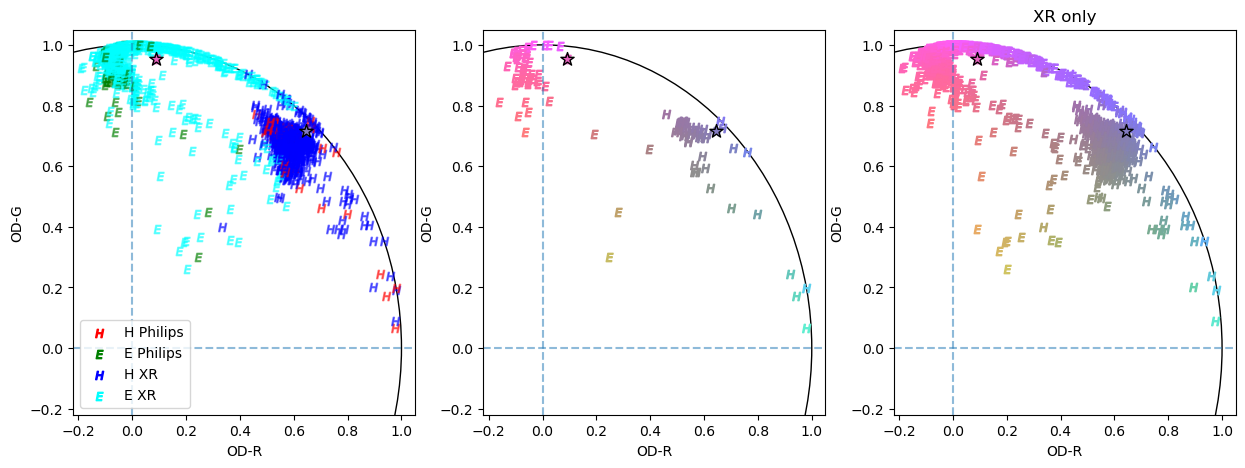

In [13]:
labels = ['OD-R','OD-G','OD-B']
fig = plt.figure(figsize=(15,5))

#plot only
i=0
j=1
index = i+j
ax = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)
titles = ['Philips vs XR', 'Philips only', 'XR only']

for p,plot in enumerate([ax, ax2, ax3]):
    circle = plt.Circle((0, 0), 1, fill=False)
    # Add circle to plot
    plot.add_patch(circle)
    plot.axhline(0, linestyle='--', alpha=0.5 )  # dashed line at y=0
    plot.axvline(0, linestyle='--', alpha=0.5 )  # dashed line at x=0
    plt.title(titles[p])
print(i,j)

s=0
for x,df_entry in macenko_stains.iterrows():
    slide = df_entry['slide']
    stain_pair = df_entry['stain']
    rgb_pair = od2rgb(stain_pair)
    if slide in slides_philips:
        ax.scatter(stain_pair[0,i], stain_pair[0,j], marker='$H$', color='red', alpha=0.5)
        ax.scatter(stain_pair[1,i], stain_pair[1,j], marker='$E$', color='green', alpha=0.5)

        ax2.scatter(stain_pair[0,i], stain_pair[0,j], marker='$H$', color=rgb_pair[0,:]/255)
        ax2.scatter(stain_pair[1,i], stain_pair[1,j], marker='$E$', color=rgb_pair[1,:]/255)

    else:
        ax.scatter(stain_pair[0,i], stain_pair[0,j], marker='$H$', color='blue', alpha=0.5)
        ax.scatter(stain_pair[1,i], stain_pair[1,j], marker='$E$', color='cyan', alpha=0.5)

        ax3.scatter(stain_pair[0,i], stain_pair[0,j], marker='$H$', color=rgb_pair[0,:]/255)
        ax3.scatter(stain_pair[1,i], stain_pair[1,j], marker='$E$', color=rgb_pair[1,:]/255)

for plot in [ax, ax2, ax3]:


    plot.set_xlabel(labels[i])
    plot.set_ylabel(labels[j])
    plot.scatter(Landini_pair[0,i], Landini_pair[0,j], marker='$H$', color=Landini_rgb[0,:]/255)
    plot.scatter(Landini_pair[1,i], Landini_pair[1,j], marker='$E$', color=Landini_rgb[1,:]/255)
    plot.scatter(Landini_pair[0,i], Landini_pair[0,j], marker='*', color=Landini_rgb[0,:]/255, edgecolors='k', s=100)
    plot.scatter(Landini_pair[1,i], Landini_pair[1,j], marker='*', color=Landini_rgb[1,:]/255, edgecolors='k', s=100)

    # Create circle
    plot.set_xlim(-0.22, 1.05)
    plot.set_ylim(-0.22, 1.05)

ax.scatter(-1, -1, marker='$H$', color='red',  label='H Philips')
ax.scatter(-1, -1, marker='$E$', color='green',  label='E Philips')
ax.scatter(-1, -1, marker='$H$', color='blue',  label='H XR')
ax.scatter(-1, -1, marker='$E$', color='cyan',  label='E XR')
ax.legend(loc=3)

0 1


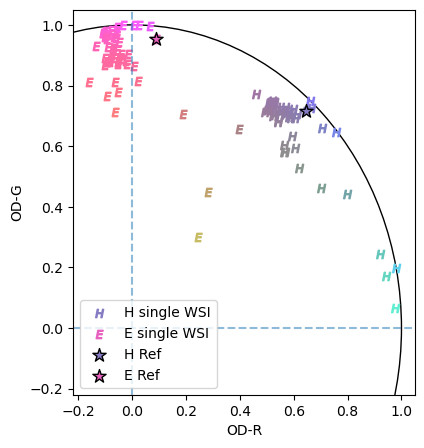

In [17]:
philips_distances = np.zeros(len(slides_philips))
sorted_slides =[]

labels = ['OD-R','OD-G','OD-B']
fig = plt.figure(figsize=(15,5))

#plot only
i=0
j=1
index = i+j
ax = fig.add_subplot(1,3,index)
circle = plt.Circle((0, 0), 1, fill=False)
# Add circle to plot
ax.add_patch(circle)
plt.axhline(0, linestyle='--', alpha=0.5 )  # dashed line at y=0
plt.axvline(0, linestyle='--', alpha=0.5 )  # dashed line at x=0
print(i,j)

s=0
for x,df_entry in macenko_stains.iterrows():
    slide = df_entry['slide']
    stain_pair = df_entry['stain']
    if slide in slides_philips:
        # distance = np.linalg.norm(stain_pair[0,:]-stain_pair[1,:])
        # distance = stain_pair[1,1]
        # distance = np.min(stain_pair)
        distance = np.linalg.norm(stain_pair-Landini_pair)+np.any(stain_pair<0)*100 #negative penalty
        philips_distances[s]=distance

        sorted_slides.append(slide)
        s+=1

        rgb_pair = od2rgb(stain_pair)
        plt.scatter(stain_pair[0,i], stain_pair[0,j], marker='$H$', color=rgb_pair[0,:]/255)
        plt.scatter(stain_pair[1,i], stain_pair[1,j], marker='$E$', color=rgb_pair[1,:]/255)

plt.xlabel(labels[i])
plt.ylabel(labels[j])
plt.scatter(Landini_pair[0,i], Landini_pair[0,j], marker='$H$', color=Landini_rgb[0,:]/255,  label='H single WSI')
plt.scatter(Landini_pair[1,i], Landini_pair[1,j], marker='$E$', color=Landini_rgb[1,:]/255,  label='E single WSI')
plt.scatter(Landini_pair[0,i], Landini_pair[0,j], marker='*', color=Landini_rgb[0,:]/255, edgecolors='k', s=100, label='H Ref')
plt.scatter(Landini_pair[1,i], Landini_pair[1,j], marker='*', color=Landini_rgb[1,:]/255, edgecolors='k', s=100, label='E Ref')
# Create circle
ax.set_xlim(-0.22, 1.05)
ax.set_ylim(-0.22, 1.05)
if(index==1):
    plt.legend(loc=3)



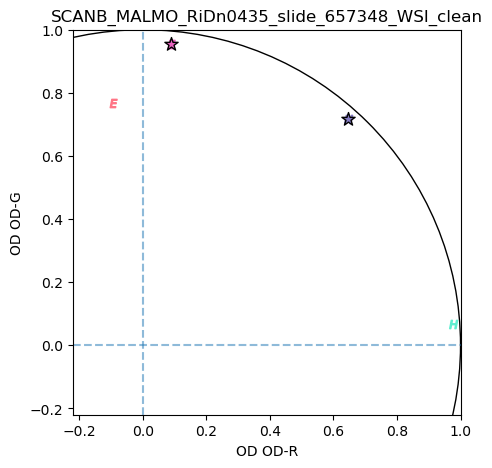

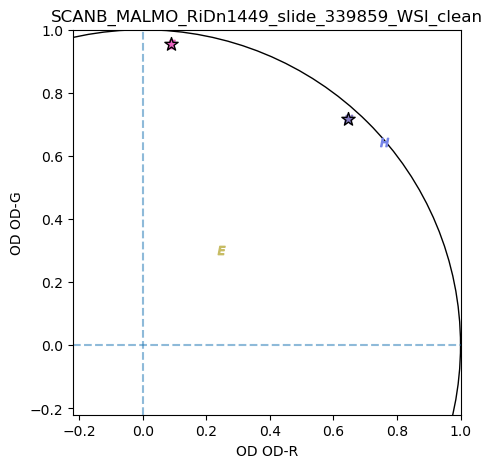

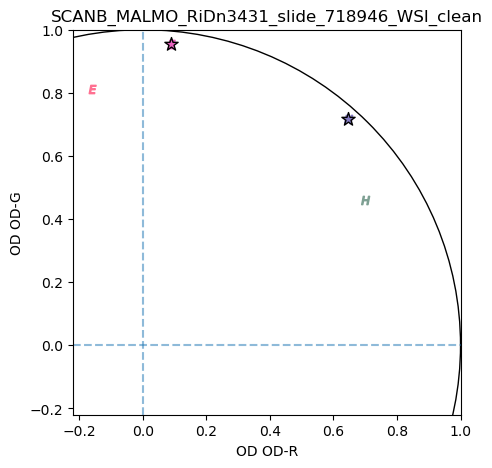

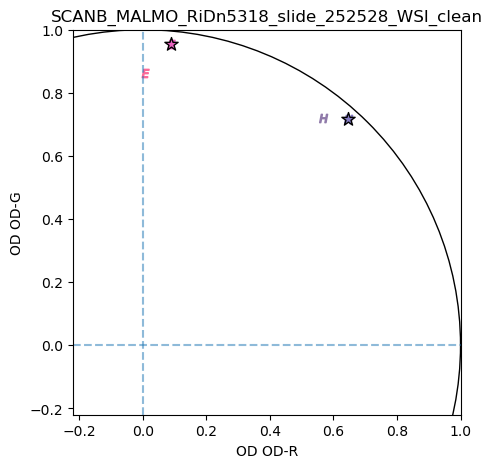

In [11]:
labels = ['OD-R','OD-G','OD-B']
slide_list = ['SCANB_MALMO_RiDn0435_slide_657348_WSI_clean','SCANB_MALMO_RiDn1449_slide_339859_WSI_clean','SCANB_MALMO_RiDn3431_slide_718946_WSI_clean', 'SCANB_MALMO_RiDn5318_slide_252528_WSI_clean']
# index = np.argmin(philips_distances)
# slide = sorted_slides[index]
# print(slide)
for slide in slide_list:
    # slide = slide_list[0]
    general_index = macenko_stains.index[macenko_stains['slide'] == slide].tolist()[0]
    stain_pair = macenko_stains['stain'][general_index]
    rgb_pair = od2rgb(stain_pair)
    fig = plt.figure(figsize=(5,5))
    ax = fig.add_subplot()
    circle = plt.Circle((0, 0), 1, fill=False)
    # Add circle to plot
    ax.add_patch(circle)
    ax.axhline(0, linestyle='--', alpha=0.5 )  # dashed line at y=0
    ax.axvline(0, linestyle='--', alpha=0.5 )  # dashed line at x=0
    i=0
    j=1

    ax.scatter(stain_pair[0,i], stain_pair[0,j], marker='$H$', color=rgb_pair[0,:]/255)
    ax.scatter(stain_pair[1,i], stain_pair[1,j], marker='$E$', color=rgb_pair[1,:]/255)
    ax.set_xlabel('OD '+labels[i])
    ax.set_ylabel('OD '+labels[j])
    ax.scatter(Landini_pair[0,i], Landini_pair[0,j], marker='$H$', color=Landini_rgb[0,:]/255,  label='H single WSI')
    ax.scatter(Landini_pair[1,i], Landini_pair[1,j], marker='$E$', color=Landini_rgb[1,:]/255,  label='E single WSI')
    ax.scatter(Landini_pair[0,i], Landini_pair[0,j], marker='*', color=Landini_rgb[0,:]/255, edgecolors='k', s=100, label='H Ref')
    ax.scatter(Landini_pair[1,i], Landini_pair[1,j], marker='*', color=Landini_rgb[1,:]/255, edgecolors='k', s=100, label='E Ref')

    # Focus
    ax.set_xlim(-0.22, 1)
    ax.set_ylim(-0.22, 1)
    plt.title(slide)


SCANB_MALMO_RiDn5318_slide_252528_WSI_clean


(-0.22, 1.0)

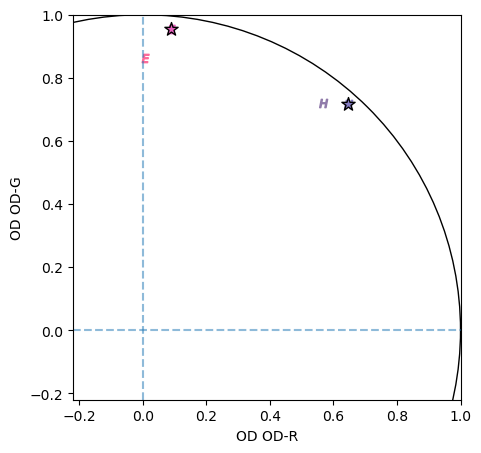

In [18]:
index = np.argmin(philips_distances)
slide = sorted_slides[index]
print(slide)
general_index = macenko_stains.index[macenko_stains['slide'] == slide].tolist()[0]
stain_pair = macenko_stains['stain'][general_index]
rgb_pair = od2rgb(stain_pair)
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot()
circle = plt.Circle((0, 0), 1, fill=False)
# Add circle to plot
ax.add_patch(circle)
ax.axhline(0, linestyle='--', alpha=0.5 )  # dashed line at y=0
ax.axvline(0, linestyle='--', alpha=0.5 )  # dashed line at x=0
i=0
j=1

ax.scatter(stain_pair[0,i], stain_pair[0,j], marker='$H$', color=rgb_pair[0,:]/255)
ax.scatter(stain_pair[1,i], stain_pair[1,j], marker='$E$', color=rgb_pair[1,:]/255)
ax.set_xlabel('OD '+labels[i])
ax.set_ylabel('OD '+labels[j])
ax.scatter(Landini_pair[0,i], Landini_pair[0,j], marker='$H$', color=Landini_rgb[0,:]/255,  label='H single WSI')
ax.scatter(Landini_pair[1,i], Landini_pair[1,j], marker='$E$', color=Landini_rgb[1,:]/255,  label='E single WSI')
ax.scatter(Landini_pair[0,i], Landini_pair[0,j], marker='*', color=Landini_rgb[0,:]/255, edgecolors='k', s=100, label='H Ref')
ax.scatter(Landini_pair[1,i], Landini_pair[1,j], marker='*', color=Landini_rgb[1,:]/255, edgecolors='k', s=100, label='E Ref')

# Focus
ax.set_xlim(-0.22, 1)
ax.set_ylim(-0.22, 1)


In [22]:
slide = macenko_stains['slide'][general_index]
print(slide)

tiles = glob.glob(original_path+slide+'/'+slide+'/*.jpg')
print(len(tiles))

SCANB_MALMO_RiDn5318_slide_252528_WSI_clean
21611


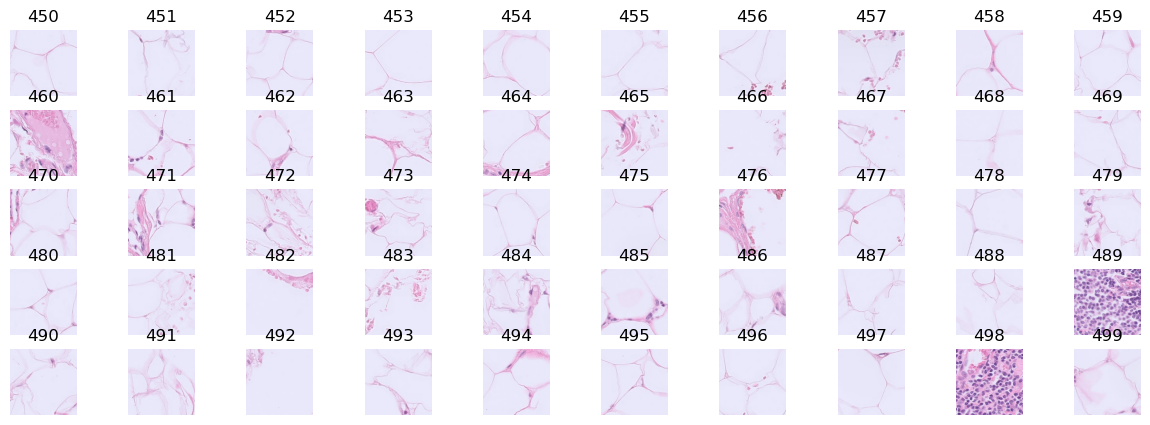

In [23]:
# Looking for interesting patches
init = 450
end = init+50
samples = [16,28,87, 114, 167, 250, 271, 458]
samples = np.arange(init,end)
plt.figure(figsize=(15,5))
for i, sample in enumerate(samples[:]):
    img_0_path = tiles[sample]
    img_0 = plt.imread(tiles[sample])
    plt.subplot(5,10,i+1)
    plt.imshow(img_0), plt.axis('off')
    plt.title(sample)


# np.random.seed(3) 
# # 3 cauterized turned H
# # 8 nice patch
# samples = [6, 18, 4, 31, 25, 61, 75, 80, 76, 137, 125, 159, 170, 186, 195, 203, 220, 224, 210]
# plt.figure(figsize=(15,5))
# for i, sample in enumerate(samples[:5]):
#     img_0_path = tiles[sample]
#     img_0 = plt.imread(tiles[sample])
#     plt.subplot(2,5,i+1)
#     plt.imshow(img_0)

#     img_macenko_path = img_0_path.replace(original_path,macenko_path).replace('.jpg','_macenko.jpg')
#     img_mac = plt.imread(img_macenko_path)
#     plt.subplot(2,5,i+1+5)
#     plt.imshow(img_mac)






In [201]:
slide = macenko_stains['slide'][general_index]
print(slide)

tiles = glob.glob(original_path+slide+'/'+slide+'/*.jpg')
print(len(tiles))

SCANB_MALMO_RiDn3431_slide_718946_WSI_clean
46469


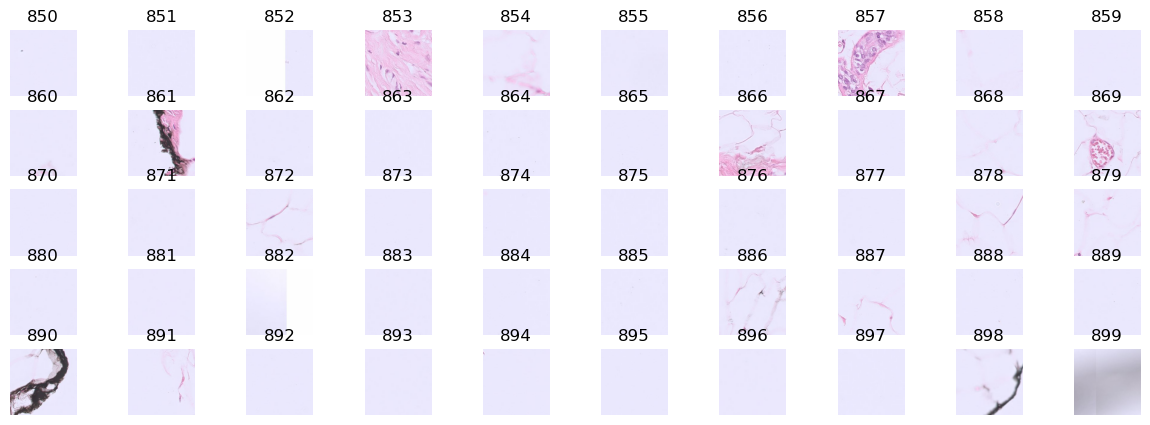

In [ ]:
# Looking for interesting patches
init = 850
end = init+50
samples = [1, 59, 143, 236, 285, 388, 592, 784, 853, 857]
samples = np.arange(init,end)
plt.figure(figsize=(15,5))
for i, sample in enumerate(samples[:]):
    img_0_path = tiles[sample]
    img_0 = plt.imread(tiles[sample])
    plt.subplot(5,10,i+1)
    plt.imshow(img_0), plt.axis('off')
    plt.title(sample)





In [ ]:
# Looking for interesting patches
init = 450
end = init+50
samples = [16,28,87, 114, 167, 250, 271, 458]
samples = np.arange(init,end)
plt.figure(figsize=(15,5))
for i, sample in enumerate(samples[:]):
    img_0_path = tiles[sample]
    img_0 = plt.imread(tiles[sample])
    plt.subplot(5,10,i+1)
    plt.imshow(img_0), plt.axis('off')
    plt.title(sample)


# np.random.seed(3) 
# # 3 cauterized turned H
# # 8 nice patch
# samples = [6, 18, 4, 31, 25, 61, 75, 80, 76, 137, 125, 159, 170, 186, 195, 203, 220, 224, 210]
# plt.figure(figsize=(15,5))
# for i, sample in enumerate(samples[:5]):
#     img_0_path = tiles[sample]
#     img_0 = plt.imread(tiles[sample])
#     plt.subplot(2,5,i+1)
#     plt.imshow(img_0)

#     img_macenko_path = img_0_path.replace(original_path,macenko_path).replace('.jpg','_macenko.jpg')
#     img_mac = plt.imread(img_macenko_path)
#     plt.subplot(2,5,i+1+5)
#     plt.imshow(img_mac)






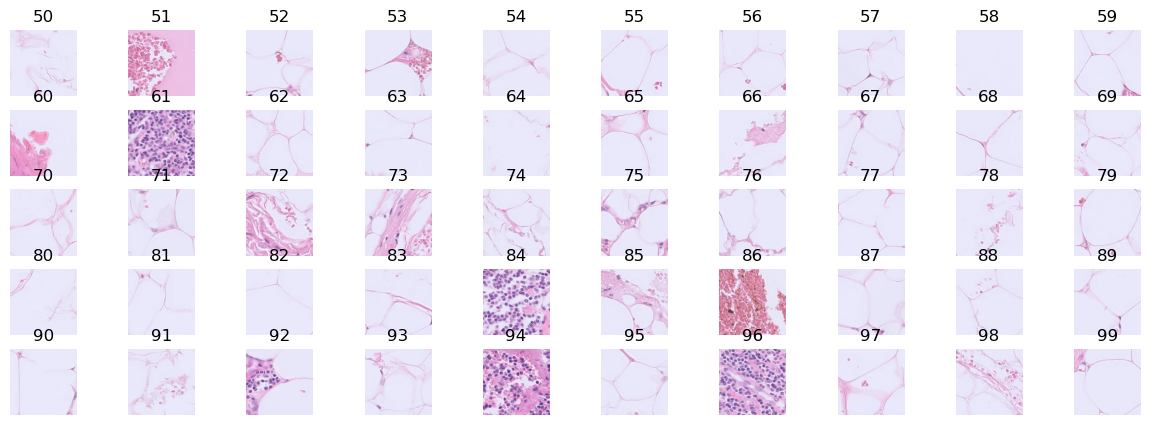

In [ ]:
# Looking for interesting patches
init = 50
end = init+50
samples = [5, 13, 28, 49, 51, 61, 86, 94, 53]
samples = np.arange(init,end)
plt.figure(figsize=(15,5))
for i, sample in enumerate(samples[:]):
    img_0_path = tiles[sample]
    img_0 = plt.imread(tiles[sample])
    plt.subplot(5,10,i+1)
    plt.imshow(img_0), plt.axis('off')
    plt.title(sample)


# np.random.seed(3) 
# # 3 cauterized turned H
# # 8 nice patch
# samples = [6, 18, 4, 31, 25, 61, 75, 80, 76, 137, 125, 159, 170, 186, 195, 203, 220, 224, 210]
# plt.figure(figsize=(15,5))
# for i, sample in enumerate(samples[:5]):
#     img_0_path = tiles[sample]
#     img_0 = plt.imread(tiles[sample])
#     plt.subplot(2,5,i+1)
#     plt.imshow(img_0)

#     img_macenko_path = img_0_path.replace(original_path,macenko_path).replace('.jpg','_macenko.jpg')
#     img_mac = plt.imread(img_macenko_path)
#     plt.subplot(2,5,i+1+5)
#     plt.imshow(img_mac)






0 1
0 2
1 2


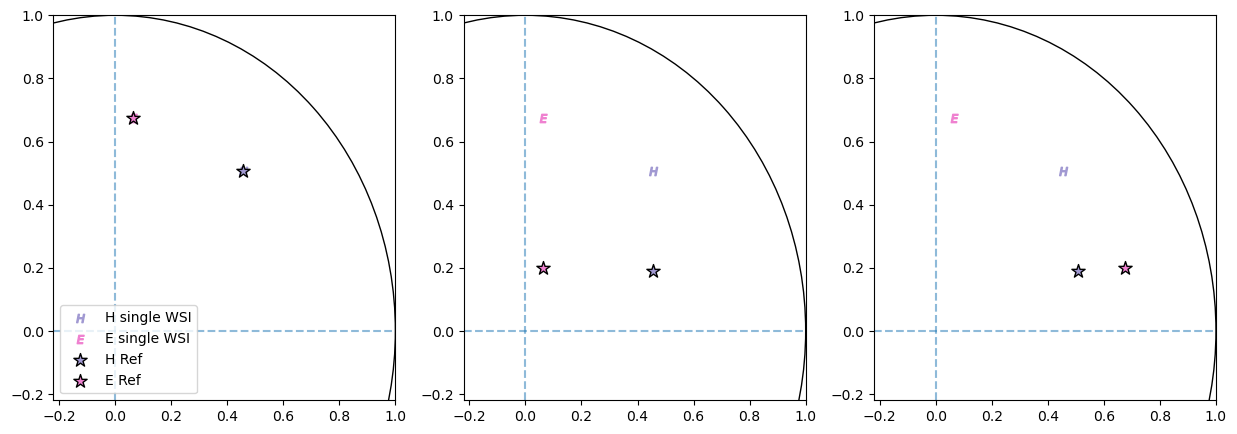

In [8]:
labels = ['OD-R','OD-G','OD-B']
fig = plt.figure(figsize=(15,5))

for i in range(3):   
    for j in range(i+1,3):
        index = i+j
        ax = fig.add_subplot(1,3,index)
        circle = plt.Circle((0, 0), 1, fill=False)
        # Add circle to plot
        ax.add_patch(circle)
        plt.axhline(0, linestyle='--', alpha=0.5 )  # dashed line at y=0
        plt.axvline(0, linestyle='--', alpha=0.5 )  # dashed line at x=0
        print(i,j)
        for stain_pair in macenko_stains['stain'][:1]:
            if not np.any(stain_pair<-1e-3):
                rgb_pair = od2rgb(stain_pair)
                plt.scatter(stain_pair[0,i], stain_pair[0,j], marker='$H$', color=rgb_pair[0,:]/255)
                plt.scatter(stain_pair[1,i], stain_pair[1,j], marker='$E$', color=rgb_pair[1,:]/255)
                plt.xlabel(labels[i])
                plt.ylabel(labels[j])
        plt.scatter(Landini_pair[0,0], Landini_pair[0,1], marker='$H$', color=Landini_rgb[0,:]/255,  label='H single WSI')
        plt.scatter(Landini_pair[1,0], Landini_pair[1,1], marker='$E$', color=Landini_rgb[1,:]/255,  label='E single WSI')
        plt.scatter(Landini_pair[0,i], Landini_pair[0,j], marker='*', color=Landini_rgb[0,:]/255, edgecolors='k', s=100, label='H Ref')
        plt.scatter(Landini_pair[1,i], Landini_pair[1,j], marker='*', color=Landini_rgb[1,:]/255, edgecolors='k', s=100, label='E Ref')
        # Create circle
        ax.set_xlim(-0.22, 1)
        ax.set_ylim(-0.22, 1)
        if(index==1):
            plt.legend(loc=3)

        


471
0.7708674304418985


In [54]:

for stain_pair in macenko_stains['stain'][:1]:
    print(stain_pair)
    print(np.linalg.norm(np.abs(stain_pair),axis=1))
    print(od2rgb(stain_pair))
    print(np.linalg.norm(od2rgb(stain_pair),axis=1))
    print()

[[ 0.53267434  0.73658198  0.41677935]
 [-0.08851263  0.94287209  0.32118177]]
[1. 1.]
[[149 121 167]
 [255  98 184]]
[254.42287633 329.37061193]



[[133 124 195]
 [232  97 191]]
[[0.6443 0.7167 0.2669]
 [0.09   0.9545 0.2832]]


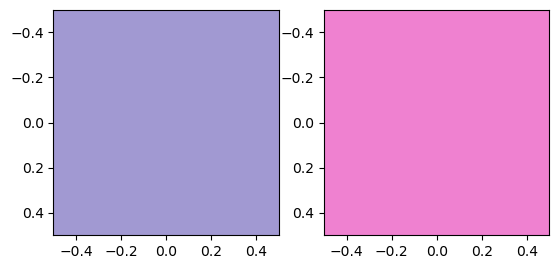

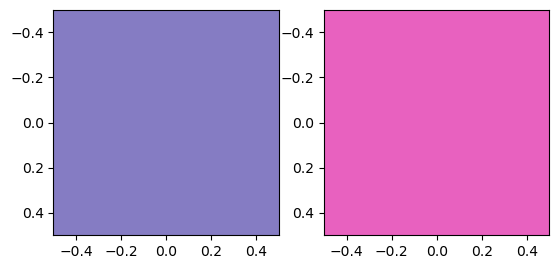

In [37]:
print(Landini_rgb)
print(Landini_pair)
Landini_norm = Landini_pair/np.linalg.norm(Landini_pair)

rgb_stain = od2rgb(Landini_norm)
rgb_stain[0,:].reshape(1,1,3)
plt.subplot(121)
plt.imshow(rgb_stain[0,:].reshape(1,1,3))
plt.subplot(122)
plt.imshow(rgb_stain[1,:].reshape(1,1,3))

plt.figure()
rgb_stain = od2rgb(Landini_pair)
rgb_stain[0,:].reshape(1,1,3)
plt.subplot(121)
plt.imshow(rgb_stain[0,:].reshape(1,1,3))
plt.subplot(122)
plt.imshow(rgb_stain[1,:].reshape(1,1,3))
